In [1]:
!pip install pymupdf faiss-cpu pillow sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 51.6 MB/s eta 0:00:00


In [2]:
import fitz
from google.colab import files
import os

uploaded = files.upload()
file_path = list(uploaded.keys())[0]

doc = fitz.open(file_path)

texts = []
image_paths = []

img_folder = "/content/images"
os.makedirs(img_folder, exist_ok=True)

for page_num in range(len(doc)):
    page = doc[page_num]

    texts.append(page.get_text())

    for i, img in enumerate(page.get_images(full=True)):
        xref = img[0]
        base = doc.extract_image(xref)
        path = f"{img_folder}/p{page_num}_{i}.png"

        with open(path, "wb") as f:
            f.write(base["image"])

        image_paths.append((page_num, path))

print("✅ Extracted:", len(texts), "pages,", len(image_paths), "images")

Saving ARCS Data sample.pdf to ARCS Data sample.pdf
✅ Extracted: 407 pages, 255 images


In [3]:
chunks = []
chunk_page_map = []

for i, text in enumerate(texts):
    for chunk in text.split("\n\n"):
        if len(chunk) > 100:
            chunks.append(chunk)
            chunk_page_map.append(i)

print("🧩 Chunks:", len(chunks))

🧩 Chunks: 406


In [4]:
from sentence_transformers import SentenceTransformer

# Text embedding model
text_model = SentenceTransformer('all-MiniLM-L6-v2')

# CLIP for images
clip_model = SentenceTransformer('clip-ViT-B-32')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

modules.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: /root/.cache/huggingface/hub/models--sentence-transformers--clip-ViT-B-32/snapshots/327ab6726d33c0e22f920c83f2ff9e4bd38ca37f/0_CLIPModel
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [5]:
import numpy as np

text_embeddings = text_model.encode(chunks)

In [6]:
from PIL import Image

image_embeddings = []
image_files = []

for page, path in image_paths:
    try:
        img = Image.open(path).convert("RGB")
        emb = clip_model.encode(img)

        image_embeddings.append(emb)
        image_files.append(path)
    except:
        continue

image_embeddings = np.array(image_embeddings)

print("🖼 Image embeddings:", len(image_embeddings))

🖼 Image embeddings: 255


In [7]:
import faiss

# Text index
text_index = faiss.IndexFlatL2(len(text_embeddings[0]))
text_index.add(np.array(text_embeddings))

# Image index
image_index = faiss.IndexFlatL2(len(image_embeddings[0]))
image_index.add(image_embeddings)

In [21]:
# Build a dictionary: page number → list of image paths
page_to_images = {}

for path in image_files:
    # Extract page number from filename like "p22_0.png"
    filename = os.path.basename(path)
    try:
        page_num = int(filename.split("_")[0].replace("p", ""))
        if page_num not in page_to_images:
            page_to_images[page_num] = []
        page_to_images[page_num].append(path)
    except:
        continue

print(f"✅ Page-to-image mapping built: {len(page_to_images)} pages have images")
for page, imgs in sorted(page_to_images.items())[:5]:
    print(f"  Page {page}: {len(imgs)} images")

✅ Page-to-image mapping built: 187 pages have images
  Page 17: 1 images
  Page 18: 1 images
  Page 21: 1 images
  Page 24: 2 images
  Page 27: 2 images


In [22]:
text_embeddings_norm = text_model.encode(chunks, normalize_embeddings=True)
text_index = faiss.IndexFlatIP(text_embeddings_norm.shape[1])
text_index.add(np.array(text_embeddings_norm))
print(f"✅ Text index rebuilt: {text_index.ntotal} vectors (normalized)")

✅ Text index rebuilt: 406 vectors (normalized)


In [33]:
from IPython.display import display, Image as IPImage
import numpy as np
import os

def extract_best_sentences(chunks_list, query, top_n=3):
    all_sentences = []
    for chunk in chunks_list:
        sentences = [s.strip() for s in chunk.replace("\n", " ").split(".") if len(s.strip()) > 20]
        all_sentences.extend(sentences)

    if not all_sentences:
        return "\n".join(chunks_list)

    query_emb = text_model.encode([query], normalize_embeddings=True)
    sent_embs = text_model.encode(all_sentences, normalize_embeddings=True)
    scores = np.dot(sent_embs, query_emb.T).flatten()
    top_indices = np.argsort(scores)[::-1][:top_n]

    best = [all_sentences[i] + "." for i in sorted(top_indices)]
    return "\n".join(best)


def chatbot():
    print("🤖 Multimodal RAG Chatbot\n")

    while True:
        query = input("🧑 Ask: ")

        if query.lower() == "exit":
            break

        # 🔹 TEXT SEARCH
        q_emb = text_model.encode([query], normalize_embeddings=True)
        D, I = text_index.search(np.array(q_emb), k=5)

        best_score = float(D[0][0])
        print(f"[DEBUG] Best text score: {best_score:.3f}")

        # 🔹 OUT-OF-PDF CHECK
        if best_score < 0.35:
            print("\n❌ This question is not related to the document.")
            print("Please ask something related to the PDF content.\n")
            print("=" * 60)
            continue

        # 🔹 GET RELEVANT CHUNKS + PAGES
        retrieved_chunks = []
        retrieved_pages = set()

        for j in range(len(I[0])):
            if float(D[0][j]) > 0.25:
                retrieved_chunks.append(chunks[I[0][j]])
                retrieved_pages.add(chunk_page_map[I[0][j]])

        if not retrieved_chunks:
            print("\n❌ No relevant content found in the document.\n")
            print("=" * 60)
            continue

        # 🔹 ANSWER
        print("\n📄 Answer:\n")
        answer = extract_best_sentences(retrieved_chunks, query, top_n=5)
        print(answer)

        # 🔹 IMAGE RETRIEVAL — based on matching PAGES, not CLIP
        print(f"\n[DEBUG] Retrieved pages: {sorted(retrieved_pages)}")
        print("\n🖼️ Relevant Images:\n")
        shown = 0

        for page in sorted(retrieved_pages):
            if page in page_to_images:
                for path in page_to_images[page]:
                    if os.path.exists(path):
                        print(f"  [Page {page}] {os.path.basename(path)}")
                        display(IPImage(filename=path))
                        shown += 1
                        if shown >= 5:
                            break
            if shown >= 5:
                break

        if shown == 0:
            print("  No images found on the relevant pages.")

        print("\n" + "=" * 60)



🤖 Multimodal RAG Chatbot

🧑 Ask: give me one Example for Creating a Chart to Display Unmatched Transactions by Account Type?
[DEBUG] Best text score: 0.750

📄 Answer:

Chart View: Unmatched Transactions by Organizational Unit This chart view displays a pie chart for the unmatched transactions for each organizational unit.
Example: Creating a Chart to Display Unmatched Transactions by Account Type This example creates a chart that plots the total value of unmatched transactions for each account type.
See Chart View: Match Types With High Unmatched Transactions.
Chart View: Match Types With High Unmatched Transactions This chart view displays match types with a high number of unmatched transactions.
The generated chart appears as follows:   Chapter 22 Example: Transaction Matching Dashboard Administering Account Reconciliation E94355-83 Copyright © 2016, 2025, Oracle and/or its affiliates.

[DEBUG] Retrieved pages: [271, 298, 299, 300, 301]

🖼️ Relevant Images:

  [Page 271] p271_0.png


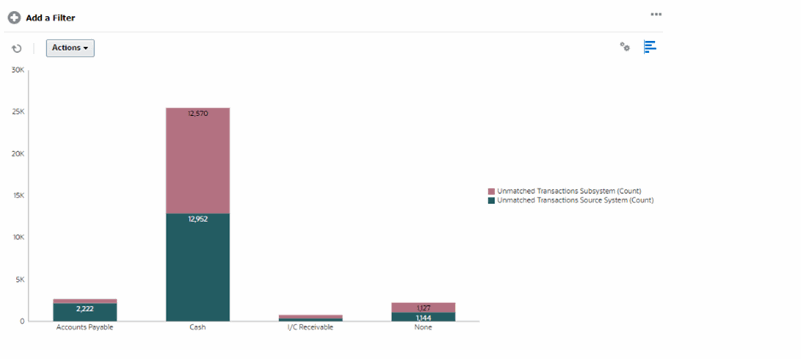

  [Page 298] p298_0.png


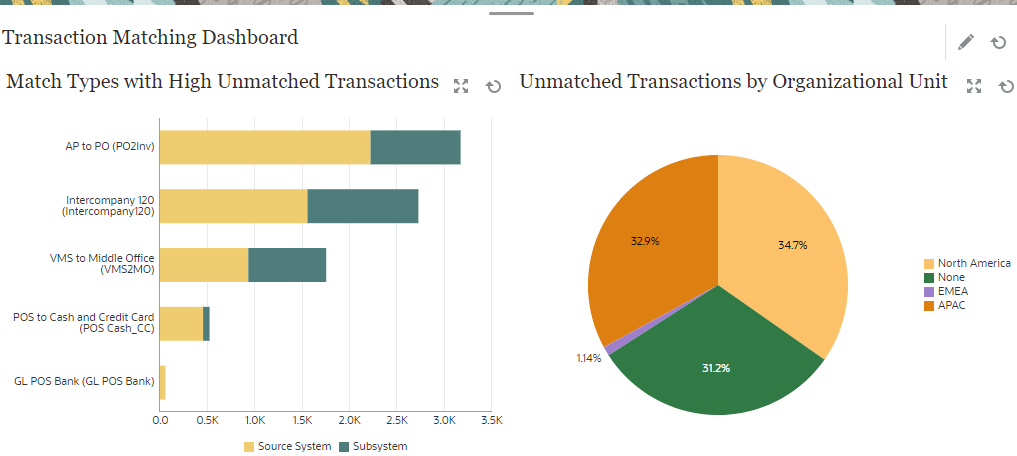

  [Page 299] p299_0.png


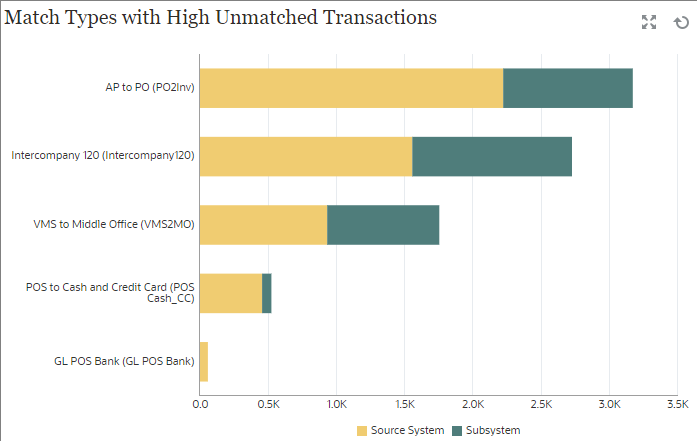

  [Page 300] p300_0.png


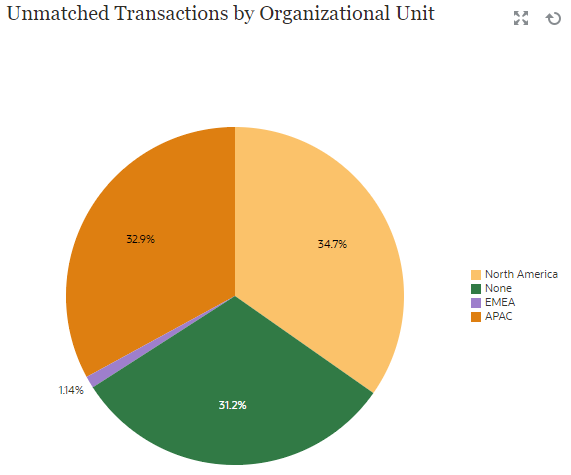


🧑 Ask: exit


In [34]:
chatbot()

In [17]:
# Rebuild with normalized embeddings
text_embeddings_norm = text_model.encode(chunks, normalize_embeddings=True)
text_index = faiss.IndexFlatIP(text_embeddings_norm.shape[1])
text_index.add(np.array(text_embeddings_norm))
print(f"✅ Text index rebuilt: {text_index.ntotal} vectors (normalized)")

✅ Text index rebuilt: 406 vectors (normalized)


In [18]:
# Normalize existing image embeddings
image_embeddings_norm = image_embeddings / np.linalg.norm(image_embeddings, axis=1, keepdims=True)
image_index = faiss.IndexFlatIP(image_embeddings_norm.shape[1])
image_index.add(image_embeddings_norm)
print(f"✅ Image index rebuilt: {image_index.ntotal} images (normalized)")

✅ Image index rebuilt: 255 images (normalized)


In [19]:
from IPython.display import display, Image as IPImage
import numpy as np
import os

def extract_best_sentences(chunks_list, query, top_n=5):
    all_sentences = []
    for chunk in chunks_list:
        sentences = [s.strip() for s in chunk.replace("\n", " ").split(".") if len(s.strip()) > 20]
        all_sentences.extend(sentences)

    if not all_sentences:
        return "\n".join(chunks_list)

    query_emb = text_model.encode([query], normalize_embeddings=True)
    sent_embs = text_model.encode(all_sentences, normalize_embeddings=True)
    scores = np.dot(sent_embs, query_emb.T).flatten()
    top_indices = np.argsort(scores)[::-1][:top_n]

    best = [all_sentences[i] + "." for i in sorted(top_indices)]
    return "\n".join(best)


def chatbot():
    print("🤖 Multimodal RAG Chatbot\n")

    while True:
        query = input("🧑 Ask: ")

        if query.lower() == "exit":
            break

        # 🔹 TEXT SEARCH
        q_emb = text_model.encode([query], normalize_embeddings=True)
        D, I = text_index.search(np.array(q_emb), k=10)

        best_score = float(D[0][0])
        print(f"[DEBUG] Best text score: {best_score:.3f}")

        # 🔹 OUT-OF-PDF CHECK (cosine scores are now 0 to 1)
        if best_score < 0.35:
            print("\n❌ This question is not related to the document.")
            print("Please ask something related to the PDF content.\n")
            print("=" * 60)
            continue

        # 🔹 GET RELEVANT CHUNKS (only above threshold)
        retrieved_chunks = []
        for j in range(len(I[0])):
            if float(D[0][j]) > 0.25:
                retrieved_chunks.append(chunks[I[0][j]])

        if not retrieved_chunks:
            print("\n❌ No relevant content found in the document.\n")
            print("=" * 60)
            continue

        # 🔹 ANSWER — extract best sentences
        print("\n📄 Answer:\n")
        answer = extract_best_sentences(retrieved_chunks, query, top_n=5)
        print(answer)

        # 🔹 IMAGE SEARCH
        q_img_emb = clip_model.encode([query], normalize_embeddings=True)
        D_img, I_img = image_index.search(np.array(q_img_emb), k=10)

        max_img_score = float(D_img[0][0])
        print(f"\n[DEBUG] Best image score: {max_img_score:.3f}")

        print("\n🖼️ Relevant Images:\n")
        shown = 0

        for score, idx in zip(D_img[0], I_img[0]):
            if idx < len(image_files):
                path = image_files[idx]
                if float(score) > 0.20 and os.path.exists(path):
                    print(f"  [Score: {score:.3f}] {os.path.basename(path)}")
                    display(IPImage(filename=path))
                    shown += 1
                    if shown >= 3:
                        break

        if shown == 0:
            print("  No relevant images found for this query.")

        print("\n" + "=" * 60)



🤖 Multimodal RAG Chatbot

🧑 Ask: what is the capital of india?
[DEBUG] Best text score: 0.124

❌ This question is not related to the document.
Please ask something related to the PDF content.

🧑 Ask: Example: Transaction Matching Dashboard?
[DEBUG] Best text score: 0.643

📄 Answer:

Searching Transactions in Transaction Matching In Transaction Matching, you can use various criteria to search for the required transactions.
The Transactions tab under the Matching card has a centralized search of transactions and adjustments for a given match type across all statuses making finding what you are looking for much easier.
Part II Administering Transaction Matching Related Topics • Learning About Transaction Matching The Transaction Matching module enables companies to save additional time spent on performing complex reconciliations, while improving quality and reducing risk.
The generated chart appears as follows:   Chapter 22 Example: Transaction Matching Dashboard Administering Account Rec

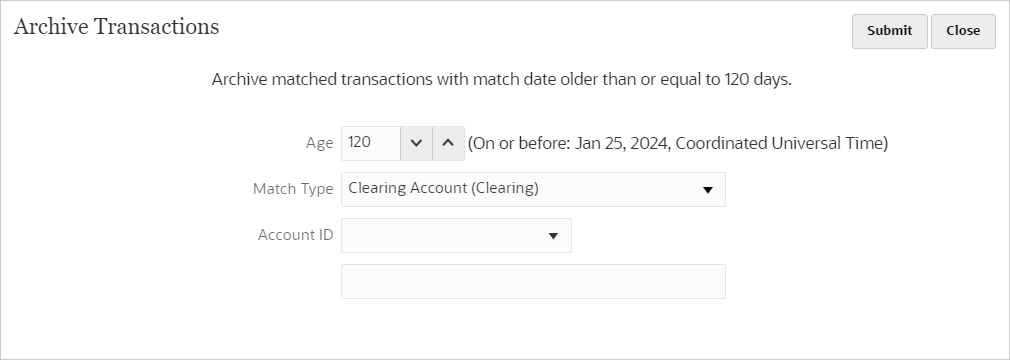

  [Score: 0.309] p300_0.png


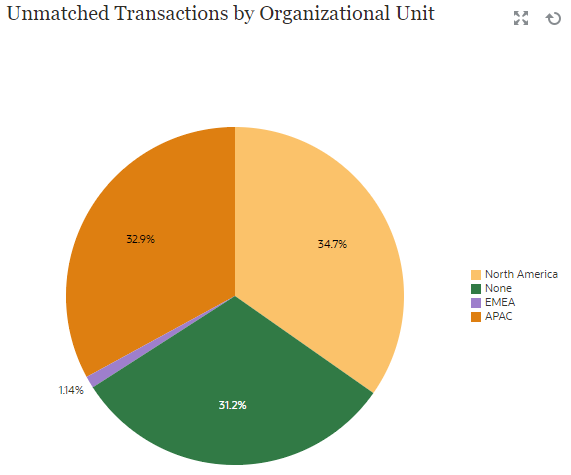

  [Score: 0.305] p326_1.png


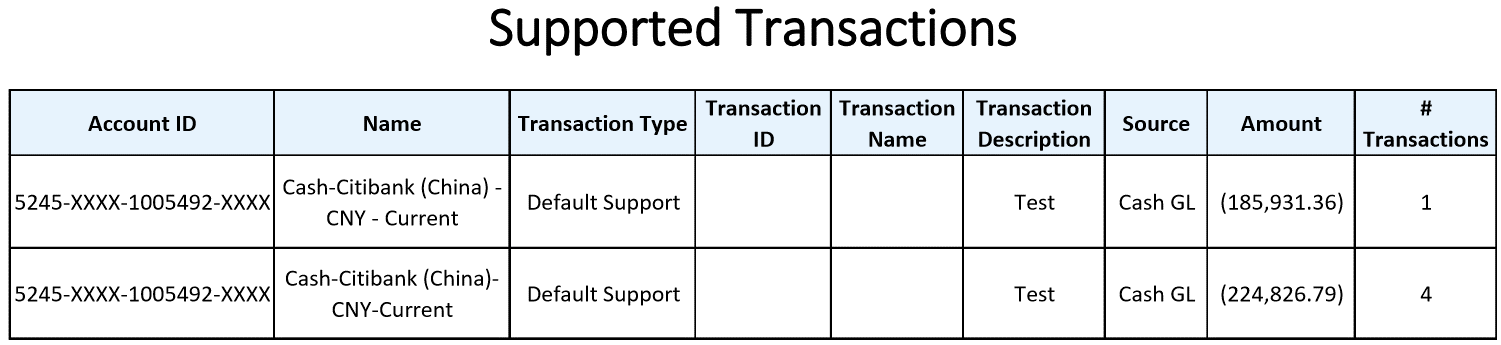


🧑 Ask: Open Reconciliations by Account Type with Balances?
[DEBUG] Best text score: 0.697

📄 Answer:

– Properties   Chapter 5 Preparing Reconciliations Administering Account Reconciliation E94355-83 Copyright © 2016, 2025, Oracle and/or its affiliates.
– Attributes     Chapter 5 Preparing Reconciliations Administering Account Reconciliation E94355-83 Copyright © 2016, 2025, Oracle and/or its affiliates.
Chapter 5 Preparing Reconciliations Administering Account Reconciliation E94355-83 Copyright © 2016, 2025, Oracle and/or its affiliates.
Users can now see the balances within all reconciliations and filter on the list.
Chapter 5 Preparing Reconciliations Administering Account Reconciliation E94355-83 Copyright © 2016, 2025, Oracle and/or its affiliates.

[DEBUG] Best image score: 0.324

🖼️ Relevant Images:

  [Score: 0.324] p326_0.png


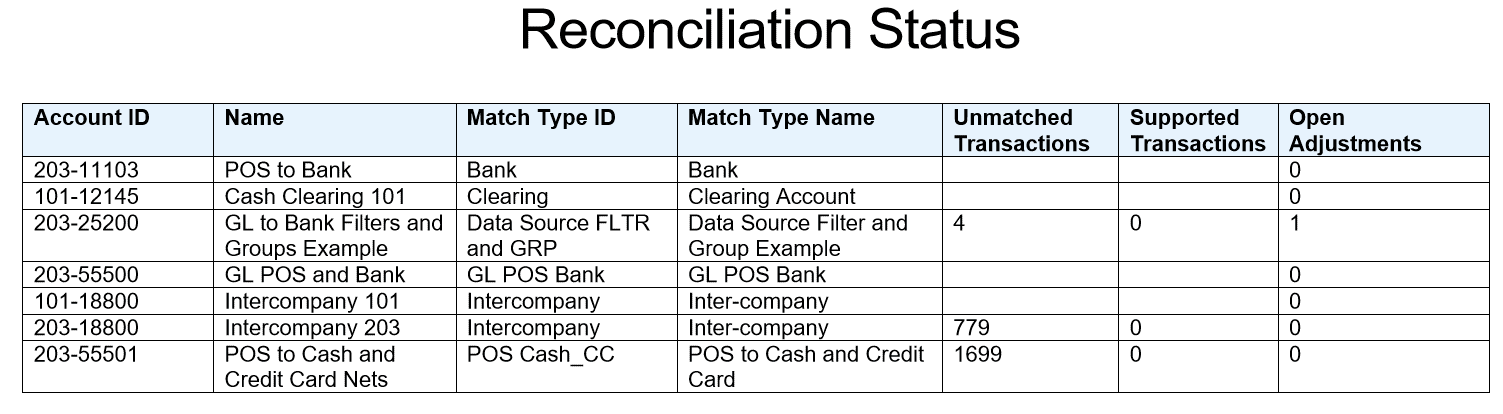

  [Score: 0.313] p292_0.png


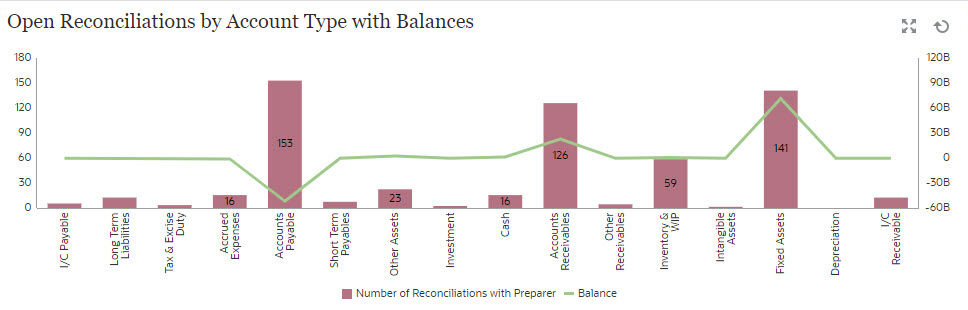

  [Score: 0.313] p83_1.png


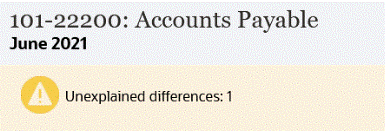


🧑 Ask: give me one Example Reconciliation Compliance Custom Dashboard?
[DEBUG] Best text score: 0.738

📄 Answer:

Example: Reconciliation Compliance Custom Dashboard This example creates a Reconciliation Compliance dashboard that contains four views.
To create the Reconciliation Compliance dashboard: 1.
• Set the Name to Reconciliation Compliance Dashboard.
Chapter 22 Example: Reconciliation Compliance Custom Dashboard Administering Account Reconciliation E94355-83 Copyright © 2016, 2025, Oracle and/or its affiliates.
Compliance Dashboard The Compliance Dashboard provides metrics on how well the company achieved their compliance objectives, distinguishing those reconciliations that were completed on time, from those that were late, and counting those that had been rejected or contain risk conditions such as debit/credit violations or aging violations.

[DEBUG] Best image score: 0.320

🖼️ Relevant Images:

  [Score: 0.320] p323_0.png


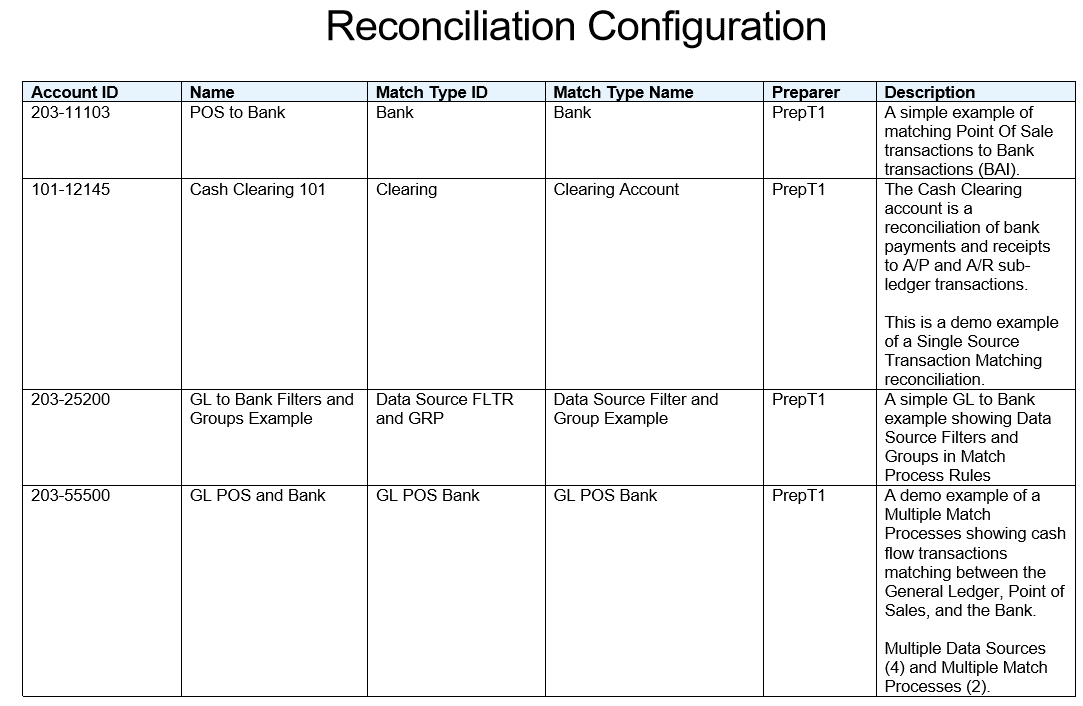

  [Score: 0.310] p346_0.png


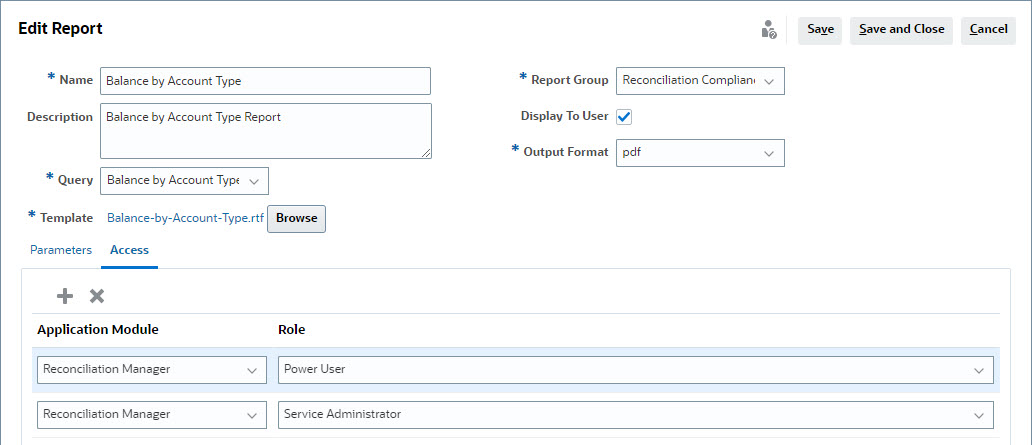

  [Score: 0.307] p246_0.png


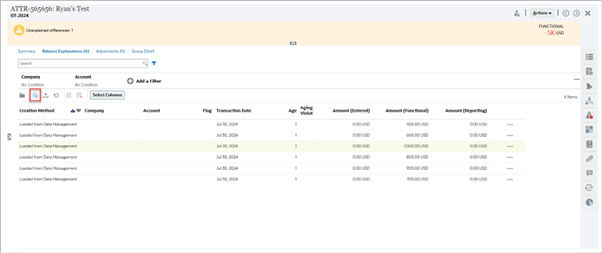


🧑 Ask: Custom Dashboards: Design Mode?
[DEBUG] Best text score: 0.632

📄 Answer:

• Control access to viewing dashboards Custom Dashboards: Design Mode The design mode of a dashboard enables you to configure and manage your dashboard and its components (chart views, list views, and pivot views).
This image shows the design mode of a custom dashboard that contains two chart views.
Figure 22-1    Custom Dashboard: Design Mode At the top-right are these options to manage the dashboard: • Settings Edit the properties of the dashboard.
See Custom Dashboards: Design Mode.
Additionally, if you're viewing the dashboard in run mode, you can click the Edit icon to switch to design mode.

[DEBUG] Best image score: 0.271

🖼️ Relevant Images:

  [Score: 0.271] p203_0.png


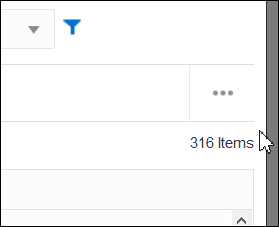

  [Score: 0.271] p40_0.png


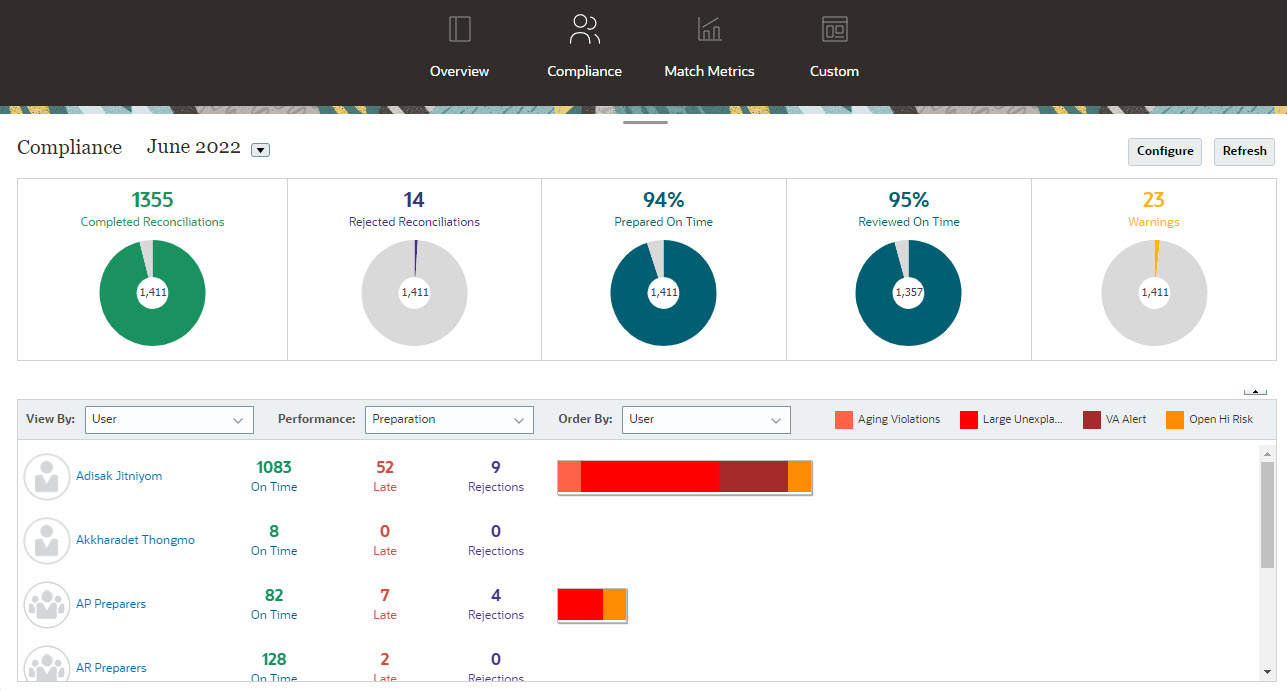

  [Score: 0.270] p192_0.png


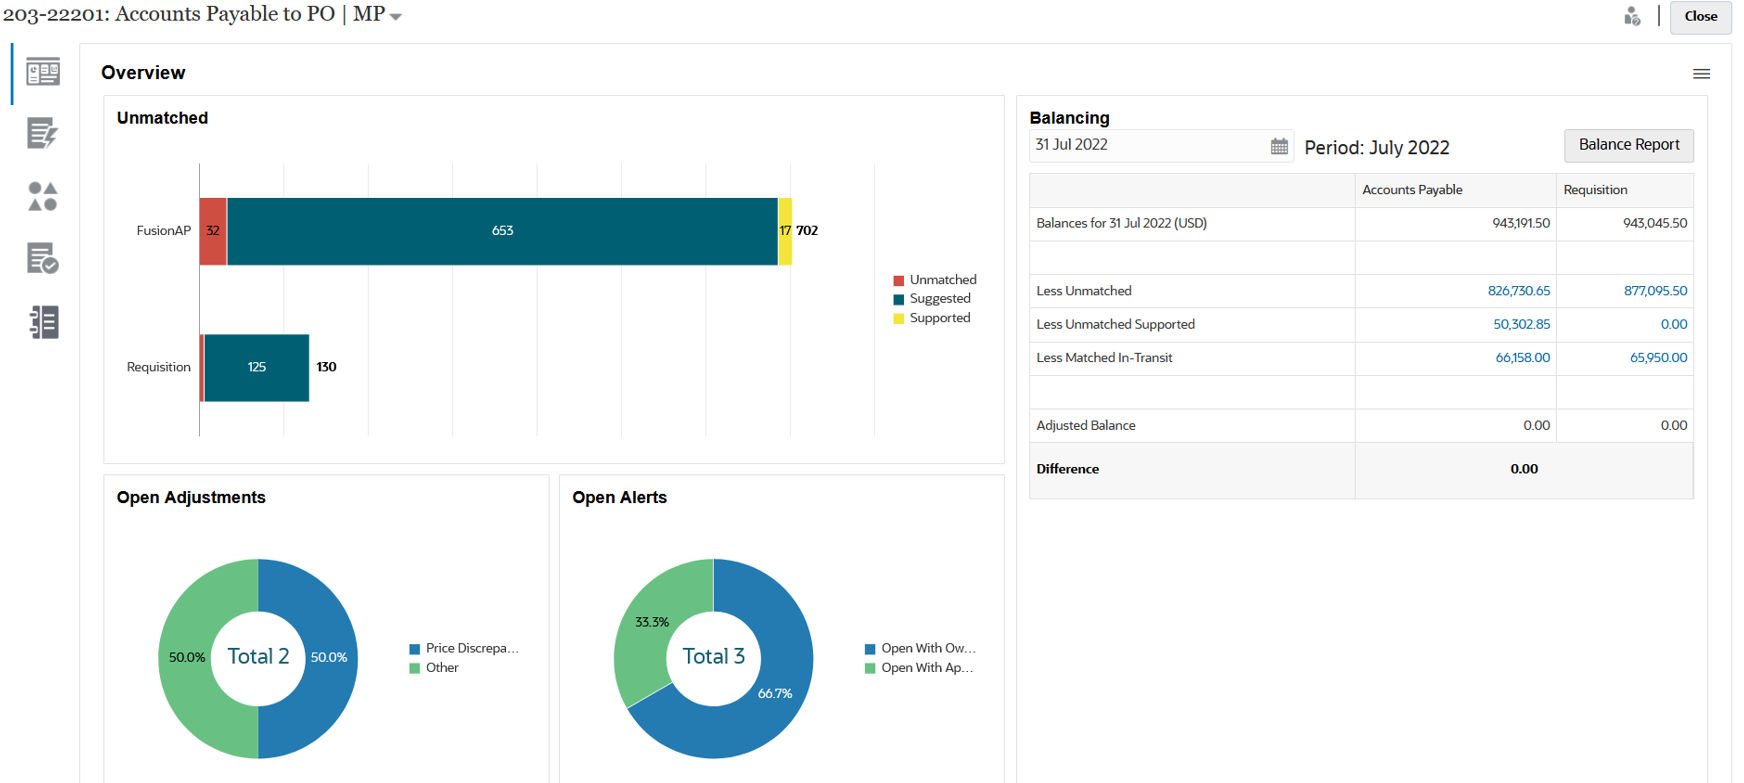


🧑 Ask: exit


In [20]:
chatbot()